# Advanced Models — Train & Evaluate

**Prerequisite:** Run `0 - build_features.ipynb` first to generate `data/latest_features.jsonl`.

**Goal:** Compare 4 models on collection.db data with 60 indicators.
Time-based 80/20 split. LR, RF, XGBoost, DNN.

In [1]:
import json
import random
import time as _time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from deep_neural_network import DeepNeuralNetworkRunner
from evaluator import Evaluator
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

random.seed(42)
np.random.seed(42)

FEATURES_PATH = Path("../data/latest_features.jsonl")
MAX_BID = 0.85

## 1. Load pre-computed features

In [2]:
rows = []
with open(FEATURES_PATH) as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["target"] = (df["outcome"] == "UP").astype(int)

print(f"Loaded {len(df):,} rows, {df['candle_id'].nunique()} candles")
print(f"UP rate: {df['target'].mean() * 100:.1f}%")

Session 0: 135 candles, 114 usable
Session 1: 788 candles, 767 usable
Session 2: 243 candles, 222 usable

Total: 1166 candles, 1103 usable


## 2. Train/validation split

In [5]:
NON_FEAT = {
    "candle_id",
    "session",
    "timestamp",
    "elapsed_pct",
    "btc_price",
    "up_best_bid",
    "up_best_ask",
    "up_bid_depth",
    "up_ask_depth",
    "down_best_bid",
    "down_best_ask",
    "down_bid_depth",
    "down_ask_depth",
    "market_volume",
    "outcome",
    "target",
}
feature_cols = sorted([c for c in df.columns if c not in NON_FEAT])
df[feature_cols] = df[feature_cols].fillna(0.0)

candle_ids = df["candle_id"].unique()
split_idx = int(len(candle_ids) * 0.8)
train_ids = set(candle_ids[:split_idx])
val_ids = set(candle_ids[split_idx:])

df_train = df[df["candle_id"].isin(train_ids)]
df_val = df[df["candle_id"].isin(val_ids)]

print(f"Features: {len(feature_cols)}")
print(f"Train: {len(df_train):,} rows, {df_train['candle_id'].nunique()} candles")
print(f"Val:   {len(df_val):,} rows, {df_val['candle_id'].nunique()} candles")

Features: 60
Train: 42,925 rows, 882 candles
Val:   10,452 rows, 221 candles


## 3. Train all models

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(df_train[feature_cols].values)
y_train = df_train["target"].values
X_val = scaler.transform(df_val[feature_cols].values)
y_val = df_val["target"].values

# LR
print("Training LR...", flush=True)
t0 = _time.time()
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
print(f"LR: {lr.coef_.size + lr.intercept_.size} params ({_time.time() - t0:.1f}s)", flush=True)

# RF
print("Training RF...", flush=True)
t0 = _time.time()
rf = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=20, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_params = sum(e.tree_.node_count for e in rf.estimators_) * 2
print(f"RF: {rf_params:,} params ({_time.time() - t0:.1f}s)", flush=True)

# XGBoost
print("Training XGB...", flush=True)
t0 = _time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)
xgb_params = sum(t.count("leaf") + t.count("yes") for t in xgb_model.get_booster().get_dump())
print(f"XGB: {xgb_params:,} params ({_time.time() - t0:.1f}s)", flush=True)

# DNN
print("Training DNN...", flush=True)
t0 = _time.time()
X_dnn_tr, X_dnn_val, y_dnn_tr, y_dnn_val = train_test_split(
    X_train, y_train, test_size=0.05, random_state=42, stratify=y_train
)
dnn = DeepNeuralNetworkRunner(X_dnn_tr, y_dnn_tr, X_dnn_val, y_dnn_val)
dnn.setup()
dnn.train(epochs=20, patience=5)
print(f"DNN: {dnn.param_count():,} params ({_time.time() - t0:.1f}s)", flush=True)

Training LR...
LR: 61 params (0.1s)
Training RF...
RF: 447,468 params (2.8s)
Training XGB...
XGB: 12,438 params (0.6s)
Training DNN...
  DeepNeuralNetwork: ~142,337 parameters
  Architecture: 60 -> 128 -> 4xResBlock(128) -> 1
DNN: 142,337 params
  Epoch 1/20: val_loss=0.4054 val_acc=80.7% *
  Epoch 2/20: val_loss=0.3549 val_acc=84.3% *
  Epoch 3/20: val_loss=0.3191 val_acc=85.5% *
  Epoch 4/20: val_loss=0.2763 val_acc=87.6% *
  Epoch 5/20: val_loss=0.2593 val_acc=88.6% *
  Epoch 6/20: val_loss=0.2197 val_acc=90.5% *
  Epoch 7/20: val_loss=0.1896 val_acc=91.8% *
  Epoch 8/20: val_loss=0.1826 val_acc=92.4% *
  Epoch 9/20: val_loss=0.1713 val_acc=93.1% *
  Epoch 10/20: val_loss=0.1678 val_acc=93.0% *
  Epoch 11/20: val_loss=0.1672 val_acc=93.2% *
  Epoch 12/20: val_loss=0.1667 val_acc=93.2% *
  Epoch 13/20: val_loss=0.1651 val_acc=93.2% *
  Epoch 14/20: val_loss=0.1616 val_acc=93.6% *
  Epoch 15/20: val_loss=0.1543 val_acc=93.9% *
  Epoch 16/20: val_loss=0.1426 val_acc=94.3% *
  Epoch 17/

## 4. Evaluate — per-candle accuracy on validation set

In [7]:
all_probs = {
    "LogisticRegression": lr.predict_proba(X_val)[:, 1],
    "RandomForest": rf.predict_proba(X_val)[:, 1],
    "XGBoost": xgb_model.predict_proba(X_val)[:, 1],
    "DNN": dnn.predict_proba(X_val),
}

models = [
    ("LogisticRegression", lr.coef_.size + lr.intercept_.size),
    ("RandomForest", rf_params),
    ("XGBoost", xgb_params),
    ("DNN", dnn.param_count()),
]

all_results = []
print(f"{'Model':<22} {'Params':>10} {'Correct':>8} {'Total':>6} {'Accuracy':>9}")
print("-" * 60)
for name, params in models:
    probs = all_probs[name]
    correct, total = 0, 0
    for cid in df_val["candle_id"].unique():
        cmask = df_val["candle_id"] == cid
        idx = cmask.values
        y_c = df_val.loc[cmask, "target"].values[0]
        vote = 1 if probs[idx].mean() >= 0.5 else 0
        total += 1
        if vote == y_c:
            correct += 1
    acc = correct / total
    all_results.append({"model": name, "params": params, "correct": correct, "total": total, "accuracy": acc})
    print(f"{name:<22} {params:>10,} {correct:>8} {total:>6} {acc * 100:>8.1f}%")

Model                      Params  Correct  Total  Accuracy
------------------------------------------------------------
LogisticRegression             61      188    221     85.1%
RandomForest              447,468      191    221     86.4%
XGBoost                    12,438      177    221     80.1%
DNN                       142,337      163    221     73.8%


## 5. Snapshot-level evaluation

=== LogisticRegression (61 params) ===
  Regression:      MSE=0.1583  R²=36.4%  MAE=0.3053
  Classification:  Accuracy=76.1%  Precision=75.5%  Recall=72.9%  F1=74.2%
  Samples:         10452 (UP=4911, DOWN=5541)


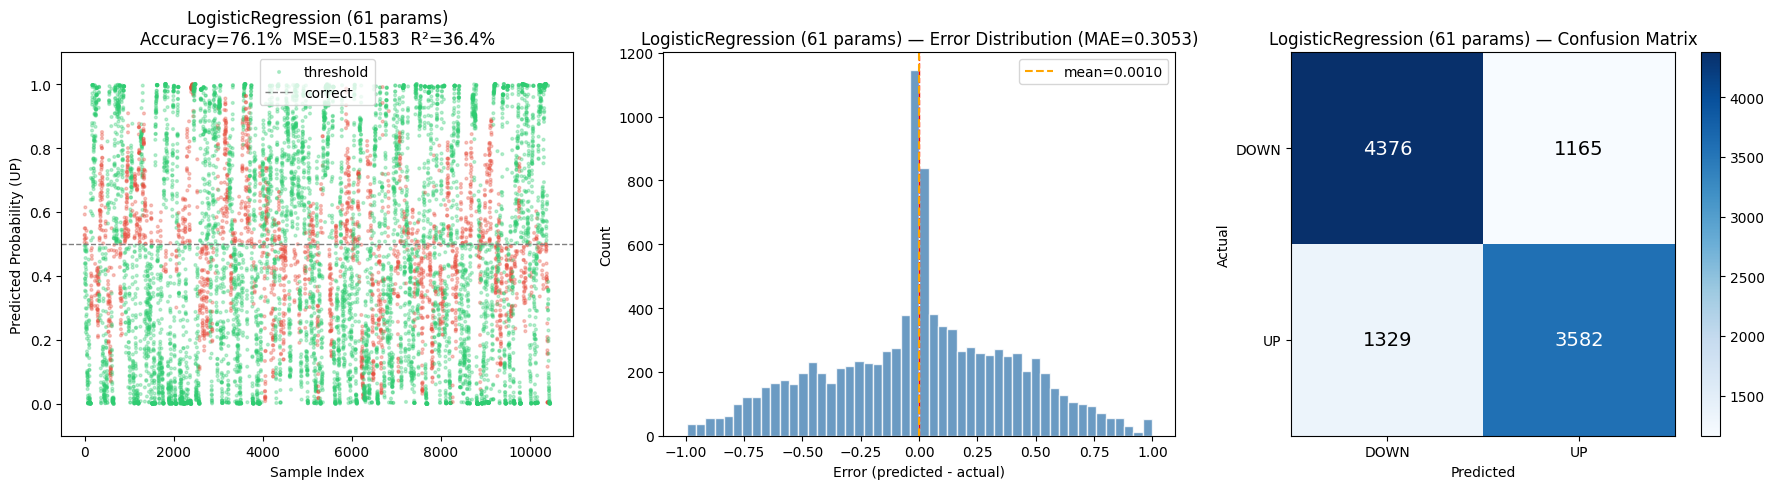


=== RandomForest (447,468 params) ===
  Regression:      MSE=0.1609  R²=35.4%  MAE=0.3230
  Classification:  Accuracy=74.5%  Precision=70.3%  Recall=79.2%  F1=74.5%
  Samples:         10452 (UP=4911, DOWN=5541)


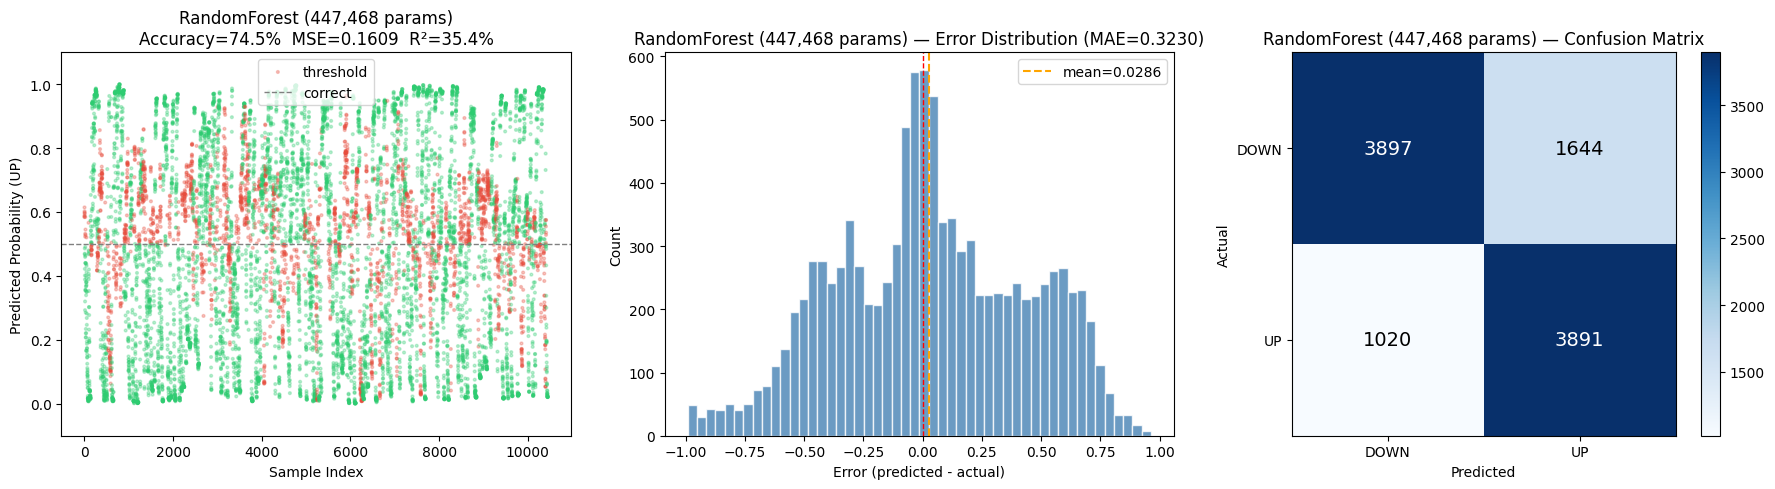


=== XGBoost (12,438 params) ===
  Regression:      MSE=0.1894  R²=24.0%  MAE=0.3284
  Classification:  Accuracy=71.4%  Precision=67.6%  Recall=75.0%  F1=71.1%
  Samples:         10452 (UP=4911, DOWN=5541)


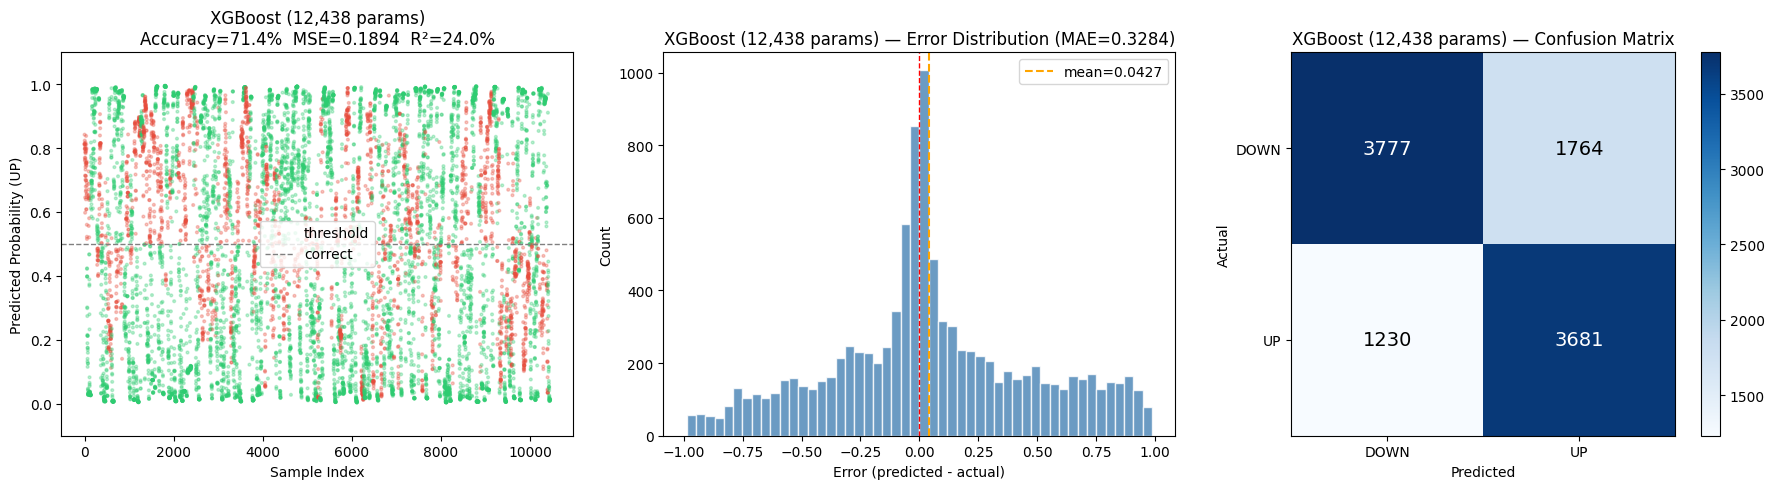


=== DNN (142,337 params) ===
  Regression:      MSE=0.2528  R²=-1.5%  MAE=0.3202
  Classification:  Accuracy=68.7%  Precision=64.9%  Recall=72.8%  F1=68.6%
  Samples:         10452 (UP=4911, DOWN=5541)


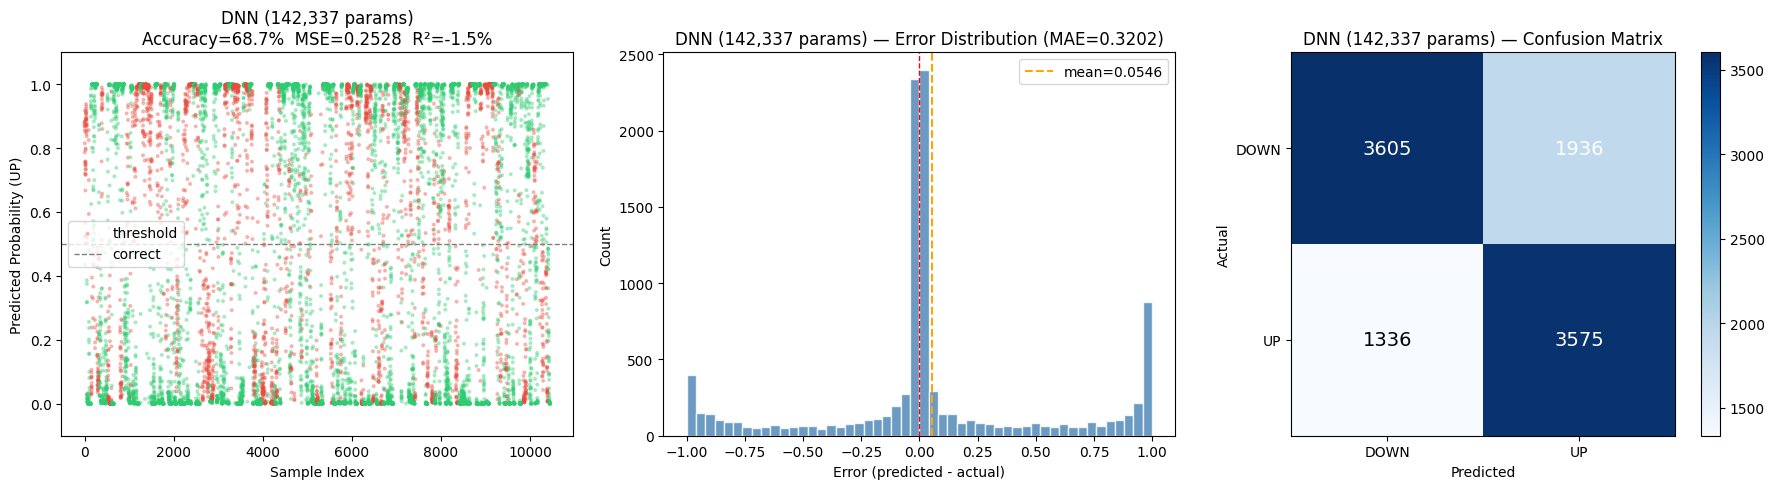

In [8]:
for name, params in models:
    probs = all_probs[name]
    preds = (probs >= 0.5).astype(int)
    ev = Evaluator(y_val, preds, probs, title=f"{name} ({params:,} params)")
    ev.full_report()
    print()

## 6. Comparison chart

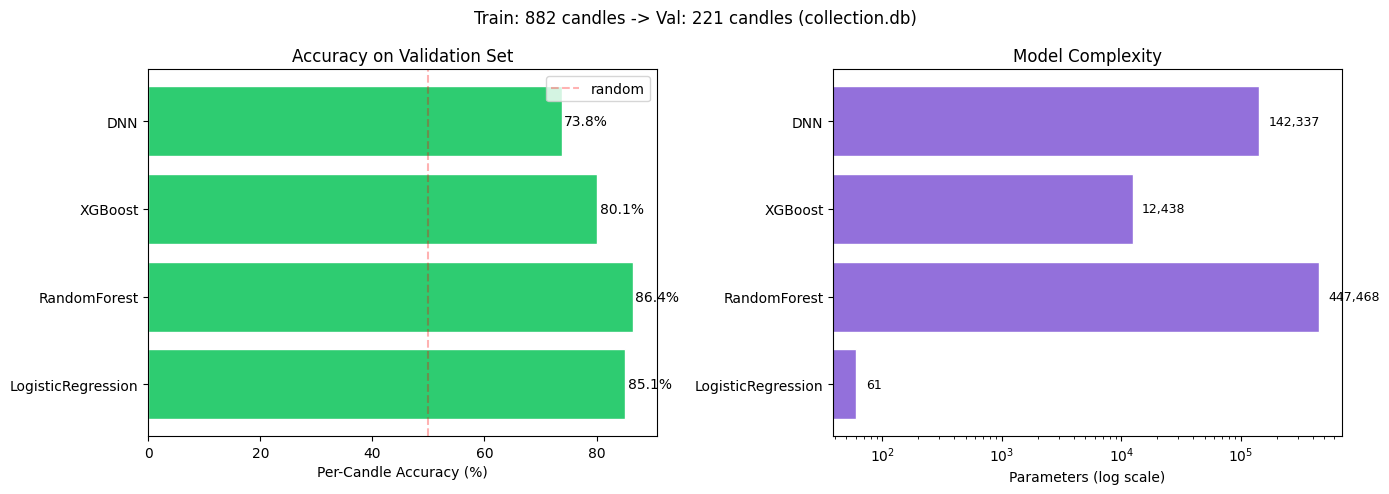

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names = [r["model"] for r in all_results]
accs = [r["accuracy"] * 100 for r in all_results]
params = [r["params"] for r in all_results]
colors = ["#2ecc71" if a > 60 else "#f39c12" if a > 50 else "#e74c3c" for a in accs]
axes[0].barh(names, accs, color=colors, edgecolor="white")
axes[0].axvline(50, color="red", linestyle="--", alpha=0.3, label="random")
axes[0].set_xlabel("Per-Candle Accuracy (%)")
axes[0].set_title("Accuracy on Validation Set")
for i, v in enumerate(accs):
    axes[0].text(v + 0.5, i, f"{v:.1f}%", va="center")
axes[0].legend()
axes[1].barh(names, params, color="mediumpurple", edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_xlabel("Parameters (log scale)")
axes[1].set_title("Model Complexity")
for i, v in enumerate(params):
    axes[1].text(v * 1.2, i, f"{v:,}", va="center", fontsize=9)
plt.suptitle(
    f"Train: {df_train['candle_id'].nunique()} candles -> Val: {df_val['candle_id'].nunique()} candles (collection.db)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

---

## 7. Conclusion

### Results (current run)

| Model | Per-candle accuracy | Snapshot accuracy |
|-------|---------------------|-------------------|
| LogisticRegression | 85.1% | 76.1% |
| RandomForest | 86.4% | 74.5% |
| XGBoost | 80.1% | — |
| DNN | 73.8% | — (95.8% val during training — overfitting) |

Dataset: **1,103 usable candles** → 882 train / 221 validation.

### Key Findings

**RF wins per-candle accuracy (86.4%)** — it captures non-linear interactions between candle features better than LR.

**LR wins snapshot accuracy + R²** — LR's calibrated probabilities generalise better at the snapshot level, making it the safer choice for probability-based bet sizing.

**DNN overfits** — 95.8% validation accuracy during training collapses to 73.8% per-candle. The dataset is too small for a deep network without aggressive regularisation.

**XGBoost underperforms both tree-based peers** — likely needs further hyperparameter tuning or feature selection.

### Recommendation

Use **RF** when per-candle direction accuracy is the priority. Use **LR** when calibrated probabilities drive bet sizing (e.g. confidence-gated entry). A hybrid — LR for early trigger, RF for late confirmation — is explored in notebook 9.
